In [48]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [49]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [50]:
train = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")

train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [51]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [52]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [53]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

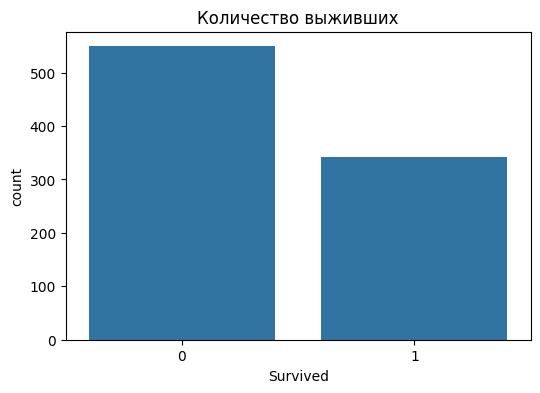

In [54]:
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=train)
plt.title("Количество выживших")
plt.show()

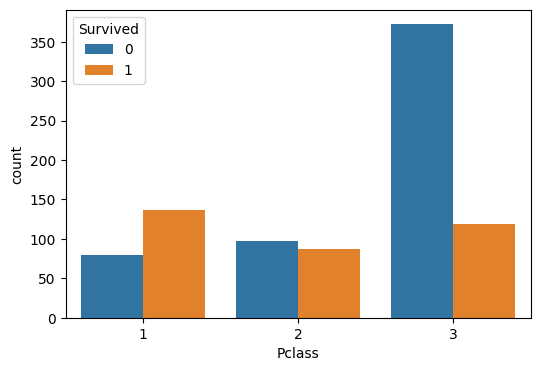

In [55]:
plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', hue='Survived', data=train)
plt.show()

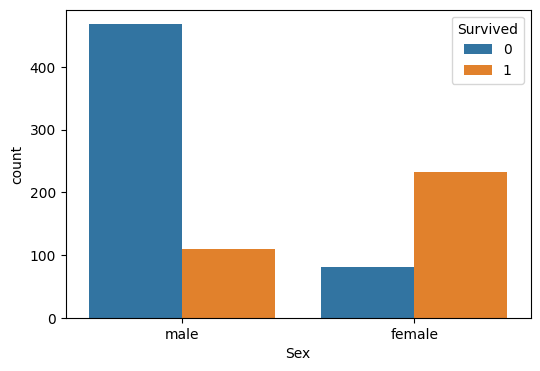

In [56]:
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Survived', data=train)
plt.show()

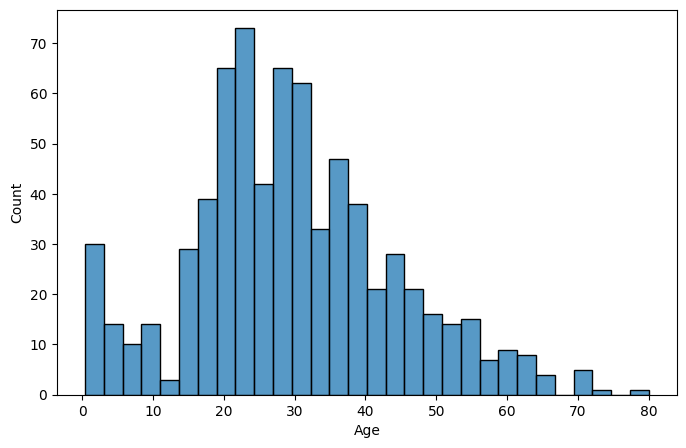

In [57]:
plt.figure(figsize=(8,5))
sns.histplot(train["Age"], bins=30)
plt.show()

In [58]:
train = train.drop(
    columns=[
        "PassengerId",
        "Name",
        "Ticket",
        "Cabin"
    ]
)

In [59]:
X = train.drop("Survived", axis=1)
y = train["Survived"]

In [62]:
categorical = ["Sex", "Embarked"]
numeric = ["Pclass","Age","SibSp","Parch","Fare"]

In [63]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric),
    ("cat", categorical_transformer, categorical)
])

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [65]:
models = {
    "Logistic Regression":
        LogisticRegression(),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),

    "XGBoost":
        XGBClassifier(
            eval_metric='logloss',
            random_state=42
        ),

    "CatBoost":
        CatBoostClassifier(
            verbose=0,
            random_state=42
        )
}

In [66]:
results = []

for name, model in models.items():

    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, pred)

    cv = cross_val_score(
        pipe,
        X,
        y,
        cv=5,
        scoring="accuracy"
    ).mean()

    results.append([name, acc, cv])

    print(name)
    print("Accuracy:", acc)
    print(classification_report(y_test, pred))
    print("-"*60)

Logistic Regression
Accuracy: 0.8100558659217877
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

------------------------------------------------------------
Decision Tree
Accuracy: 0.776536312849162
              precision    recall  f1-score   support

           0       0.82      0.79      0.81       105
           1       0.72      0.76      0.74        74

    accuracy                           0.78       179
   macro avg       0.77      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179

------------------------------------------------------------
Random Forest
Accuracy: 0.8044692737430168
              precision    recall  f1-score   support

           0       0.82      0.85  

In [67]:
results = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Test Accuracy",
        "CV Accuracy"
    ]
)

results.sort_values(
    by="CV Accuracy",
    ascending=False
)

,Model,Test Accuracy,CV Accuracy
4,CatBoost,0.826816,0.823803
3,XGBoost,0.793296,0.810357
2,Random Forest,0.804469,0.804752
0,Logistic Regression,0.810056,0.787892
1,Decision Tree,0.776536,0.780051


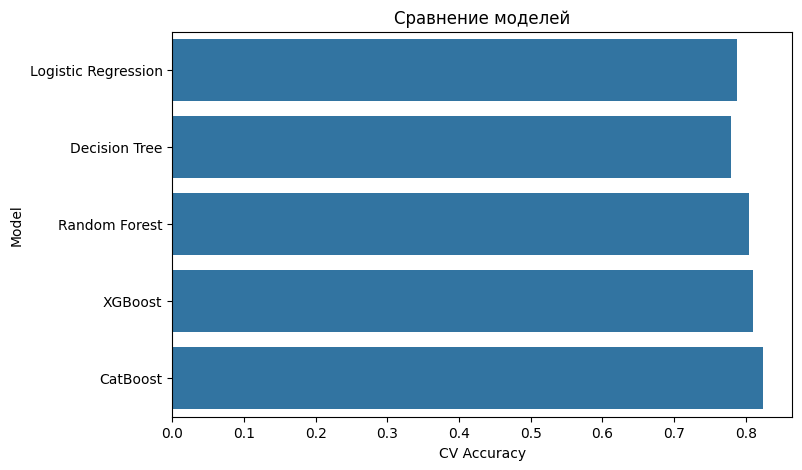

In [68]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="CV Accuracy",
    y="Model"
)

plt.title("Сравнение моделей")
plt.show()

In [69]:
best = results.sort_values(
    "CV Accuracy",
    ascending=False
)

best

,Model,Test Accuracy,CV Accuracy
4,CatBoost,0.826816,0.823803
3,XGBoost,0.793296,0.810357
2,Random Forest,0.804469,0.804752
0,Logistic Regression,0.810056,0.787892
1,Decision Tree,0.776536,0.780051


In [70]:
pipe = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

pipe.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Parch', 'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked'])])),
                ('model',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [71]:
feature_names = pipe.named_steps["prep"].get_feature_names_out()

importance = pipe.named_steps["model"].feature_importances_

imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

imp = imp.sort_values(
    by="Importance",
    ascending=False
)

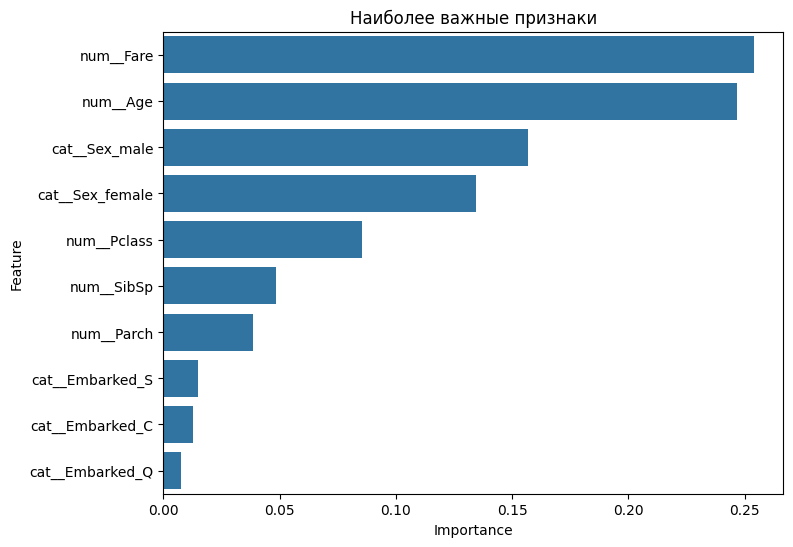

In [72]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=imp.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Наиболее важные признаки")
plt.show()

In [77]:
test = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")

In [79]:
passenger_id = test["PassengerId"]

In [80]:
test = test.drop(
    columns=[
        "PassengerId",
        "Name",
        "Ticket",
        "Cabin"
    ]
)

In [81]:
best_model = Pipeline([
    ("prep", preprocessor),
    ("model", CatBoostClassifier(
        verbose=0,
        random_state=42
    ))
])

best_model.fit(X, y)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Parch', 'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked'])])),
                ('model', CatBoostClassifier(random_state=42, verbose=0))])

In [82]:
predictions = best_model.predict(test)

In [85]:
submission = pd.DataFrame({
    "PassengerId": passenger_id,
    "Survived": predictions.astype(int)
})

In [86]:
submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0


In [87]:
print(submission.shape)

(418, 2)


In [88]:
submission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   PassengerId  418 non-null    int64
 1   Survived     418 non-null    int64
dtypes: int64(2)
memory usage: 6.7 KB


In [90]:
submission.to_csv("submission.csv", index=False)